У цьому ДЗ ми потренуємось розв'язувати задачу багатокласової класифікації за допомогою логістичної регресії з використанням стратегій One-vs-Rest та One-vs-One, оцінити якість моделей та порівняти стратегії.

### Опис задачі і даних

**Контекст**

В цьому ДЗ ми працюємо з даними про сегментацію клієнтів.

Сегментація клієнтів – це практика поділу бази клієнтів на групи індивідів, які схожі між собою за певними критеріями, що мають значення для маркетингу, такими як вік, стать, інтереси та звички у витратах.

Компанії, які використовують сегментацію клієнтів, виходять з того, що кожен клієнт є унікальним і що їхні маркетингові зусилля будуть більш ефективними, якщо вони орієнтуватимуться на конкретні, менші групи зі зверненнями, які ці споживачі вважатимуть доречними та які спонукатимуть їх до купівлі. Компанії також сподіваються отримати глибше розуміння уподобань та потреб своїх клієнтів з метою виявлення того, що кожен сегмент цінує найбільше, щоб точніше адаптувати маркетингові матеріали до цього сегменту.

**Зміст**.

Автомобільна компанія планує вийти на нові ринки зі своїми існуючими продуктами (P1, P2, P3, P4 і P5). Після інтенсивного маркетингового дослідження вони дійшли висновку, що поведінка нового ринку схожа на їхній існуючий ринок.

На своєму існуючому ринку команда з продажу класифікувала всіх клієнтів на 4 сегменти (A, B, C, D). Потім вони здійснювали сегментовані звернення та комунікацію з різними сегментами клієнтів. Ця стратегія працювала для них надзвичайно добре. Вони планують використати ту саму стратегію на нових ринках і визначили 2627 нових потенційних клієнтів.

Ви маєте допомогти менеджеру передбачити правильну групу для нових клієнтів.

В цьому ДЗ використовуємо дані `customer_segmentation_train.csv`[скачати дані](https://drive.google.com/file/d/1VU1y2EwaHkVfr5RZ1U4MPWjeflAusK3w/view?usp=sharing). Це `train.csv`з цього [змагання](https://www.kaggle.com/datasets/abisheksudarshan/customer-segmentation/data?select=train.csv)

**Завдання 1.** Завантажте та підготуйте датасет до аналізу. Виконайте обробку пропущених значень та необхідне кодування категоріальних ознак. Розбийте на тренувальну і тестувальну вибірку, де в тесті 20%. Памʼятаємо, що весь препроцесинг ліпше все ж тренувати на тренувальній вибірці і на тестувальній лише використовувати вже натреновані трансформери.
Але в даному випадку оскільки значень в категоріях небагато, можна зробити обробку і на оригінальних даних, а потім розбити - це простіше. Можна також реалізувати процесинг і тренування моделі з пайплайнами. Обирайте як вам зручніше.

In [40]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, OrdinalEncoder
from imblearn.over_sampling import SMOTENC
from imblearn.combine import SMOTETomek
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

In [41]:
# Read data
raw_df = pd.read_csv('customer_segmentation_train.csv')
raw_df

,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
0,462809,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4,D
1,462643,Female,Yes,38,Yes,Engineer,NaN,Average,3.0,Cat_4,A
2,466315,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6,B
3,461735,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6,B
4,462669,Female,Yes,40,Yes,Entertainment,NaN,High,6.0,Cat_6,A
...,...,...,...,...,...,...,...,...,...,...,...
8063,464018,Male,No,22,No,NaN,0.0,Low,7.0,Cat_1,D
8064,464685,Male,No,35,No,Executive,3.0,Low,4.0,Cat_4,D
8065,465406,Female,No,33,Yes,Healthcare,1.0,Low,1.0,Cat_6,D
8066,467299,Female,No,27,Yes,Healthcare,1.0,Low,4.0,Cat_6,B


In [42]:
# Check columns info
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8068 entries, 0 to 8067
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               8068 non-null   int64  
 1   Gender           8068 non-null   object 
 2   Ever_Married     7928 non-null   object 
 3   Age              8068 non-null   int64  
 4   Graduated        7990 non-null   object 
 5   Profession       7944 non-null   object 
 6   Work_Experience  7239 non-null   float64
 7   Spending_Score   8068 non-null   object 
 8   Family_Size      7733 non-null   float64
 9   Var_1            7992 non-null   object 
 10  Segmentation     8068 non-null   object 
dtypes: float64(2), int64(2), object(7)
memory usage: 693.5+ KB


In [43]:
# Check target column values
target_col = 'Segmentation'
raw_df[target_col].value_counts()

Segmentation
D    2268
A    1972
C    1970
B    1858
Name: count, dtype: int64

In [44]:
# Encode target with numbers
map_target = {'A': 0, 'B': 1, 'C': 2, 'D': 3}
raw_df[target_col] = raw_df[target_col].map(map_target)
raw_df[target_col]

0       3
1       0
2       1
3       1
4       0
       ..
8063    3
8064    3
8065    3
8066    1
8067    1
Name: Segmentation, Length: 8068, dtype: int64

In [45]:
# Split to train and test
train_df, test_df = train_test_split(
    raw_df, test_size=0.2, random_state=1111, stratify=raw_df[target_col])

display(train_df.head()), display(test_df.head())

,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
3726,460913,Male,NaN,22,No,Healthcare,1.0,Low,5.0,Cat_4,3
6202,464373,Female,No,46,Yes,Artist,0.0,Low,2.0,Cat_6,1
5575,465914,Female,No,46,Yes,Artist,3.0,Low,2.0,Cat_6,1
3240,467667,Male,Yes,28,No,Doctor,8.0,Low,2.0,Cat_6,0
2502,461148,Male,NaN,37,Yes,Artist,1.0,Average,3.0,Cat_3,0


,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
4602,461538,Female,No,38,Yes,Artist,8.0,Low,8.0,Cat_2,1
3799,465892,Male,No,40,Yes,Artist,9.0,Low,3.0,Cat_6,0
4613,460822,Male,Yes,41,Yes,Artist,0.0,Low,2.0,Cat_6,0
7467,460614,Male,NaN,38,Yes,Entertainment,NaN,Average,4.0,Cat_3,2
3739,461091,Female,Yes,37,Yes,Artist,3.0,Average,3.0,Cat_3,1


(None, None)

In [46]:
# Define inputs and targets
train_inputs = train_df.drop(columns=['ID', target_col])
train_target = train_df[target_col]

test_inputs = test_df.drop(columns=['ID', target_col])
test_target = test_df[target_col]

In [47]:
# Function to show info about number of missed values
def show_missed(df):
    missed_in_columns = df.isnull().sum()
    missed_values_df = pd.DataFrame({
        'column': df.columns,
        'values_missed': missed_in_columns,
        'missed_percent': round(100 * missed_in_columns / df.shape[0], 2)
    }).sort_values(by='values_missed', ascending=False)
    return missed_values_df

In [48]:
# Show missed values for train inputs
show_missed(train_inputs)

,column,values_missed,missed_percent
Work_Experience,Work_Experience,656,10.16
Family_Size,Family_Size,274,4.25
Ever_Married,Ever_Married,108,1.67
Profession,Profession,102,1.58
Graduated,Graduated,60,0.93
Var_1,Var_1,58,0.90
Gender,Gender,0,0.00
Age,Age,0,0.00
Spending_Score,Spending_Score,0,0.00


In [49]:
# Define numeric and categorial columns
numeric_cols = train_inputs.select_dtypes('number').columns
categorial_cols = train_inputs.select_dtypes('object').columns

numeric_cols, categorial_cols

(Index(['Age', 'Work_Experience', 'Family_Size'], dtype='object'),
 Index(['Gender', 'Ever_Married', 'Graduated', 'Profession', 'Spending_Score',
        'Var_1'],
       dtype='object'))

In [50]:
# Check statistics for numeric columns
train_inputs[numeric_cols].describe()

,Age,Work_Experience,Family_Size
count,6454.000000,5798.000000,6180.000000
mean,43.383483,2.639186,2.848706
std,16.694175,3.408611,1.529213
min,18.000000,0.000000,1.000000
25%,30.000000,0.000000,2.000000
50%,40.000000,1.000000,3.000000
75%,53.000000,4.000000,4.000000
max,89.000000,14.000000,9.000000


In [51]:
# Show missed values for numeric inputs
missed_in_num = show_missed(train_inputs[numeric_cols])
missed_in_num

,column,values_missed,missed_percent
Work_Experience,Work_Experience,656,10.16
Family_Size,Family_Size,274,4.25
Age,Age,0,0.00


Work_Experience
1.0     1911
0.0     1844
9.0      385
8.0      368
2.0      222
3.0      204
4.0      204
7.0      158
5.0      156
6.0      153
10.0      42
11.0      40
14.0      39
12.0      36
13.0      36
Name: count, dtype: int64


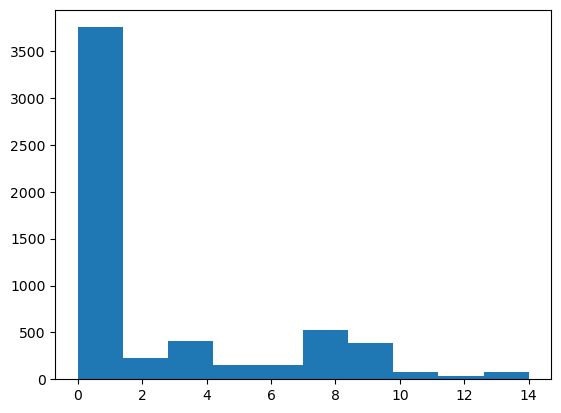

Family_Size
2.0    1891
3.0    1219
1.0    1166
4.0    1106
5.0     474
6.0     170
7.0      80
8.0      40
9.0      34
Name: count, dtype: int64


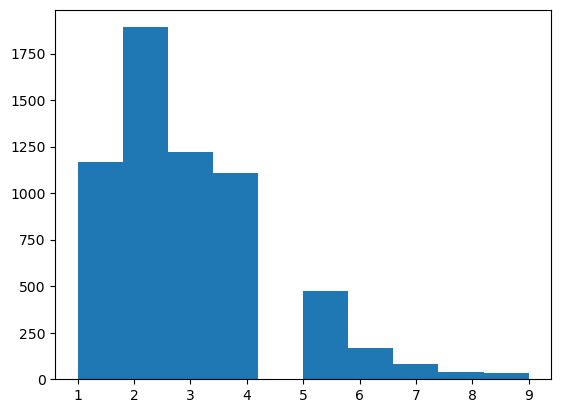

In [52]:
# Show values information for each numeric column with missed values
missed_in_num_cols = missed_in_num[missed_in_num.values_missed > 0].column.to_list()
for col in missed_in_num_cols:
    print(train_inputs[col].value_counts())

    plt.hist(train_inputs[col])
    plt.show()

Для числових колонок я використаю `SimpleImputer(strategy='median')`.

In [53]:
# Show missed values for categorial inputs
missed_in_cat = show_missed(train_inputs[categorial_cols])
missed_in_cat

,column,values_missed,missed_percent
Ever_Married,Ever_Married,108,1.67
Profession,Profession,102,1.58
Graduated,Graduated,60,0.93
Var_1,Var_1,58,0.90
Gender,Gender,0,0.00
Spending_Score,Spending_Score,0,0.00


In [54]:
# Show value counts for each categorial column
for col in categorial_cols:
    print(f"--- {col} ---")
    print(train_inputs[col].value_counts(), "\n")

--- Gender ---
Gender
Male      3565
Female    2889
Name: count, dtype: int64 

--- Ever_Married ---
Ever_Married
Yes    3704
No     2642
Name: count, dtype: int64 

--- Graduated ---
Graduated
Yes    3969
No     2425
Name: count, dtype: int64 

--- Profession ---
Profession
Artist           2027
Healthcare       1064
Entertainment     775
Engineer          567
Doctor            554
Lawyer            488
Executive         473
Marketing         220
Homemaker         184
Name: count, dtype: int64 

--- Spending_Score ---
Spending_Score
Low        3898
Average    1593
High        963
Name: count, dtype: int64 

--- Var_1 ---
Var_1
Cat_6    4211
Cat_4     865
Cat_3     643
Cat_2     339
Cat_7     163
Cat_1     109
Cat_5      66
Name: count, dtype: int64 



Для категоріальних даних я не буду заповнювати пропущені значення і залишу це на `OneHotEncoder`, який створить для них окремі категорії.

In [55]:
# Preparing preprocessor for both numeric and categorial columns
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', MinMaxScaler())
])
categorial_transformer = Pipeline([
    ('encoder', OneHotEncoder(sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_cols),
    ('cat', categorial_transformer, categorial_cols)
])
preprocessor.set_output(transform="pandas")

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


In [56]:
# Fit and transform data with preprocessor
preprocessor.fit(train_inputs)
train_inputs = preprocessor.transform(train_inputs)
test_inputs = preprocessor.transform(test_inputs)

**Завдання 2. Важливо уважно прочитати все формулювання цього завдання до кінця!**

Застосуйте методи ресемплингу даних SMOTE та SMOTE-Tomek з бібліотеки imbalanced-learn до тренувальної вибірки. В результаті у Вас має вийти 2 тренувальних набори: з апсемплингом зі SMOTE, та з ресамплингом з SMOTE-Tomek.

Увага! В нашому наборі даних є як категоріальні дані, так і звичайні числові. Базовий SMOTE не буде правильно працювати з категоріальними даними, але є його модифікація, яка буде. Тому в цього завдання є 2 виконання

  1. Застосувати SMOTE базовий лише на НЕкатегоріальних ознаках.

  2. Переглянути інформацію про метод [SMOTENC](https://imbalanced-learn.org/dev/references/generated/imblearn.over_sampling.SMOTENC.html#imblearn.over_sampling.SMOTENC) і використати цей метод в цій задачі. За цей спосіб буде +3 бали за це завдання і він рекомендований для виконання.

  **Підказка**: аби скористатись SMOTENC треба створити змінну, яка містить індекси ознак, які є категоріальними (їх номер серед колонок) і передати при ініціації екземпляра класу `SMOTENC(..., categorical_features=cat_feature_indeces)`.
  
  Ви також можете розглянути варіант використання варіації SMOTE, який працює ЛИШЕ з категоріальними ознаками [SMOTEN](https://imbalanced-learn.org/dev/references/generated/imblearn.over_sampling.SMOTEN.html)

In [57]:
# Re-define inputs and targets
train_inputs = train_df.drop(columns=['ID', target_col])
train_target = train_df[target_col]

test_inputs = test_df.drop(columns=['ID', target_col])
test_target = test_df[target_col]

In [58]:
# Re-defining preprocessor with OrdinalEncoder
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', MinMaxScaler())
])
categorial_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing_value')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_cols),
    ('cat', categorial_transformer, categorial_cols)
])

preprocessor.set_output(transform="pandas")

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


In [59]:
# Fit and transform data with preprocessor
preprocessor.fit(train_inputs)
train_inputs = preprocessor.transform(train_inputs)
test_inputs = preprocessor.transform(test_inputs)

display(train_inputs), display(test_inputs)

,num__Age,num__Work_Experience,num__Family_Size,cat__Gender,cat__Ever_Married,cat__Graduated,cat__Profession,cat__Spending_Score,cat__Var_1
3726,0.056338,0.071429,0.500,1.0,2.0,0.0,5.0,2.0,3.0
6202,0.394366,0.000000,0.125,0.0,0.0,1.0,0.0,2.0,5.0
5575,0.394366,0.214286,0.125,0.0,0.0,1.0,0.0,2.0,5.0
3240,0.140845,0.571429,0.125,1.0,1.0,0.0,1.0,2.0,5.0
2502,0.267606,0.071429,0.250,1.0,2.0,1.0,0.0,0.0,2.0
...,...,...,...,...,...,...,...,...,...
392,0.169014,0.571429,0.375,0.0,1.0,1.0,0.0,2.0,5.0
4134,0.295775,0.571429,0.125,0.0,1.0,1.0,6.0,1.0,5.0
4723,0.239437,0.000000,0.250,0.0,1.0,1.0,0.0,2.0,5.0
3876,0.197183,0.071429,0.250,0.0,0.0,1.0,2.0,2.0,2.0


,num__Age,num__Work_Experience,num__Family_Size,cat__Gender,cat__Ever_Married,cat__Graduated,cat__Profession,cat__Spending_Score,cat__Var_1
4602,0.281690,0.571429,0.875,0.0,0.0,1.0,0.0,2.0,1.0
3799,0.309859,0.642857,0.250,1.0,0.0,1.0,0.0,2.0,5.0
4613,0.323944,0.000000,0.125,1.0,1.0,1.0,0.0,2.0,5.0
7467,0.281690,0.071429,0.375,1.0,2.0,1.0,3.0,0.0,2.0
3739,0.267606,0.214286,0.250,0.0,1.0,1.0,0.0,0.0,2.0
...,...,...,...,...,...,...,...,...,...
2970,0.422535,0.714286,0.250,1.0,1.0,1.0,6.0,2.0,5.0
1224,0.352113,0.000000,0.375,1.0,1.0,1.0,4.0,1.0,5.0
4872,0.619718,0.642857,0.000,0.0,1.0,1.0,0.0,2.0,5.0
3010,0.563380,0.000000,0.125,1.0,1.0,1.0,0.0,0.0,5.0


(None, None)

In [60]:
# Define numerical and categorial columns after transformation
num_cols_transformed = train_inputs.columns[train_inputs.columns.str.startswith('num_')]
cat_cols_transformed = train_inputs.columns[train_inputs.columns.str.startswith('cat_')]

num_cols_transformed, cat_cols_transformed

(Index(['num__Age', 'num__Work_Experience', 'num__Family_Size'], dtype='object'),
 Index(['cat__Gender', 'cat__Ever_Married', 'cat__Graduated', 'cat__Profession',
        'cat__Spending_Score', 'cat__Var_1'],
       dtype='object'))

In [61]:
# Create datasets using resampling
cat_indices = train_inputs.columns.get_indexer(cat_cols_transformed).tolist()

smotenc = SMOTENC(
    categorical_features=cat_indices,
    random_state=8
)
train_inputs_smotenc, train_target_smotenc = smotenc.fit_resample(
    train_inputs, train_target)

smote_tomek = SMOTETomek(
    random_state=8,
    smote=SMOTENC(
        categorical_features=cat_indices,
        random_state=8
    )
)
train_inputs_smote_tomek, train_target_smote_tomek = smote_tomek.fit_resample(
    train_inputs, train_target)

print('SMOTENC:', train_inputs_smotenc.shape, train_target_smotenc.shape)
print('SMOTE-Tomek:', train_inputs_smote_tomek.shape, train_target_smote_tomek.shape)

SMOTENC: (7256, 9) (7256,)
SMOTE-Tomek: (5674, 9) (5674,)


**Завдання 3**.
  1. Навчіть модель логістичної регресії з використанням стратегії One-vs-Rest з логістичною регресією на оригінальних даних, збалансованих з SMOTE, збалансованих з Smote-Tomek.  
  2. Виміряйте якість кожної з натренованих моделей використовуючи `sklearn.metrics.classification_report`.
  3. Напишіть, яку метрику ви обрали для порівняння моделей.
  4. Яка модель найкраща?
  5. Якщо немає суттєвої різниці між моделями - напишіть свою гіпотезу, чому?

In [62]:
# Function to fit the model and to get prediction
def fit_and_predict(train_inputs, train_target, test_inputs):
    ovr_model = OneVsRestClassifier(LogisticRegression())
    ovr_model.fit(train_inputs, train_target)

    train_pred = ovr_model.predict(train_inputs)
    test_pred = ovr_model.predict(test_inputs)

    return {
        'train_pred': train_pred,
        'test_pred': test_pred,
    }

In [63]:
# Get predictions for 3 data sets
results_original = fit_and_predict(train_inputs, train_target, test_inputs)

results_smotenc = fit_and_predict(train_inputs_smotenc,
                                  train_target_smotenc,
                                  test_inputs)

results_smote_tomek = fit_and_predict(train_inputs_smote_tomek,
                                      train_target_smote_tomek,
                                      test_inputs)

In [64]:
# Show classification report for oriiginal dataset
print('--- ORIGINAL TRAIN ---')
print(classification_report(train_target, results_original['train_pred']))
print('--- ORIGINAL TEST ---')
print(classification_report(test_target, results_original['test_pred']))

--- ORIGINAL TRAIN ---
              precision    recall  f1-score   support

           0       0.40      0.42      0.41      1578
           1       0.34      0.07      0.11      1486
           2       0.47      0.64      0.54      1576
           3       0.59      0.77      0.67      1814

    accuracy                           0.49      6454
   macro avg       0.45      0.47      0.43      6454
weighted avg       0.46      0.49      0.45      6454

--- ORIGINAL TEST ---
              precision    recall  f1-score   support

           0       0.39      0.41      0.40       394
           1       0.33      0.07      0.12       372
           2       0.46      0.61      0.53       394
           3       0.57      0.74      0.65       454

    accuracy                           0.48      1614
   macro avg       0.44      0.46      0.42      1614
weighted avg       0.44      0.48      0.43      1614



In [65]:
# Show classification report for SMOTE dataset
print('--- SMOTE TRAIN ---')
print(classification_report(train_target_smotenc, results_smotenc['train_pred']))
print('--- SMOTE TEST ---')
print(classification_report(test_target, results_smotenc['test_pred']))

--- SMOTE TRAIN ---
              precision    recall  f1-score   support

           0       0.41      0.43      0.42      1814
           1       0.36      0.14      0.20      1814
           2       0.47      0.61      0.53      1814
           3       0.58      0.75      0.65      1814

    accuracy                           0.48      7256
   macro avg       0.46      0.48      0.45      7256
weighted avg       0.46      0.48      0.45      7256

--- SMOTE TEST ---
              precision    recall  f1-score   support

           0       0.41      0.42      0.42       394
           1       0.34      0.15      0.20       372
           2       0.48      0.60      0.53       394
           3       0.60      0.73      0.66       454

    accuracy                           0.49      1614
   macro avg       0.46      0.48      0.45      1614
weighted avg       0.47      0.49      0.46      1614



In [66]:
# Show classification report for SMOTE-Tomek dataset
print('--- SMOTE-Tomek TRAIN ---')
print(classification_report(train_target_smote_tomek, results_smote_tomek['train_pred']))
print('--- SMOTE-Tomek TEST ---')
print(classification_report(test_target, results_smote_tomek['test_pred']))

--- SMOTE-Tomek TRAIN ---
              precision    recall  f1-score   support

           0       0.43      0.45      0.44      1363
           1       0.38      0.12      0.19      1386
           2       0.50      0.66      0.57      1465
           3       0.63      0.80      0.71      1460

    accuracy                           0.52      5674
   macro avg       0.48      0.51      0.48      5674
weighted avg       0.49      0.52      0.48      5674

--- SMOTE-Tomek TEST ---
              precision    recall  f1-score   support

           0       0.40      0.42      0.41       394
           1       0.34      0.13      0.19       372
           2       0.47      0.60      0.53       394
           3       0.60      0.73      0.66       454

    accuracy                           0.48      1614
   macro avg       0.45      0.47      0.45      1614
weighted avg       0.46      0.48      0.46      1614



In [67]:
# Show value counts for all 3 datasets
print('ORIGINAL\n', train_target.value_counts(), '\n')
print('SMOTE\n', train_target_smotenc.value_counts(), '\n')
print('SMOTE-Tomek\n', train_target_smote_tomek.value_counts(), '\n')

ORIGINAL
 Segmentation
3    1814
0    1578
2    1576
1    1486
Name: count, dtype: int64 

SMOTE
 Segmentation
3    1814
1    1814
0    1814
2    1814
Name: count, dtype: int64 

SMOTE-Tomek
 Segmentation
2    1465
3    1460
1    1386
0    1363
Name: count, dtype: int64 



**Висновки**

- Для порівняння результатів обрав метрику `f1-score macro avg`, тому що ми використовуємо тут балансування класів і нам вони однаково цікаві.
- Моделі, натреновані на збалансованих даних, показали дещо кращі результати. Я би обрав модель `SMOTE`, тому що хоч вона і має менший показник на Трейні, ніж `SMOTE-Tomek`, вона має такий самий показник на Тесті. Це може свідчити про деякий оверфіт моделі `SMOTE-Tomek`.
- Великої різниці між моделями немає, бо від початку класи були доволі збалансовані. Тобто балансування трохи покращило результати.